# Método Iterativo de Jacobi: questao 1 

# Nova seção

Seja o sistema de equações lineares 
 $\left\{
\begin{aligned}
    3.2x_1 + 1.8x_2     &= 5\\
    -1.1x_1+3.1x_2 &= 2
\end{aligned}
\right. $  

com solução exata $ \mathbf{x} = (1;1)$. 


*   (a) Avalie os autovalores da matriz **D**, tal que **Ax = b** é equivalente a **x = Dx + c**.
*   (b) Execute o método iterativo de Jacobi por 30 iterações, ou pare antes de $MAX_{x_i}|x_i^{(k+1)} - x_i^{(k)}| < 10^{-8}$ com $i=1,2$, partindo da solução inicial $ \mathbf{x}^{(0)}=(0;0)$
*   (c) Refaça o item (a) para a condição inicial $ \mathbf{x}^{(0)}=(-100;300)$.


. 

*(a)* O sistema **Ax = b**, onde 

 $\mathbf{A} = \left[ 
  \begin{array}{c}
  3.2 & 1.8 \\
  -1.1 & 3.1
  \end{array}
 \right]$  e  $\mathbf{b} = \left[ 
  \begin{array}{c}
  5 \\
  2
  \end{array}
 \right]$ 
 
 pode ser reescrito na forma **x = Dx + c**, onde

  $\mathbf{D} = \left[ 
  \begin{array}{c}
  0 & -1.8/3.2 \\
  1.1/3.1 & 0
  \end{array}
 \right]$  e  $\mathbf{c} = \left[ 
  \begin{array}{c}
  5/3.2 \\
  2/3.1
  \end{array}
 \right]$

Se TODOS os autovalores de **D**, forem EM MÓDULO, menores que 1, o sistema iterativo **x = Dx + c** irá convergir para uma solução aproximada (próxima da solução exata), partindo de qualquer condição inicial, em um número finito de iterações! Se algum autovalor da matriz **D** for em módulo, maior ou igual a 1, nada pode ser dito sobre a convergência.

Vamos definir as matrizes **A** e **D**, os vetores **b** e **c**, e calcular os autovalores de **D**:

In [9]:
import numpy as np
n = 2
A = [[3.2, 1.8],[-1.1, 3.1]]  # matriz dos coeficientes do sistema linear
b = [5, 2]                    # vetor com os termos independentes
print('A =')
print('', np.matrix(A))
print('b =', np.matrix(b))
D = np.zeros((n,n))           # definicao de uma matriz de zeros
D[0][1] = -A[0][1]/A[0][0]
D[1][0] = -A[1][0]/A[1][1]
c = np.zeros(n)
c[0] = b[0]/A[0][0]
c[1] = b[1]/A[1][1]
print('D = \n', np.matrix(D))
print('c =\n', np.matrix(c))

autovalores = np.linalg.eigvals(D)  # calcula autovalores de uma matriz
print('autovalores de D = ',np.matrix(autovalores))
print('modulo dos autovalores = ',np.abs(autovalores))


A =
 [[ 3.2  1.8]
 [-1.1  3.1]]
b = [[5 2]]
D = 
 [[ 0.         -0.5625    ]
 [ 0.35483871  0.        ]]
c =
 [[1.5625     0.64516129]]
autovalores de D =  [[0.+0.44676255j 0.-0.44676255j]]
modulo dos autovalores =  [0.44676255 0.44676255]


 A conclusão *a priori*, é que o sistema irá CONVERGIR para uma solução aproximada, em um número finito de iterações.

*(b)* Agora aplicando o método de Jacobi para a primeira solução inicial $ \mathbf{x}^{(0)} =  \mathbf{x}_{ant} = (0;0)$ para o processo iterativo $\mathbf{x}^{(k+1)} = \mathbf{Dx}^{(k)} + \mathbf{c}$, ou seja:

$\left[ 
  \begin{array}{c}
  x_1^{(k+1)} \\
  x_2^{(k+1)}
  \end{array}
 \right] = 
 \left[ 
  \begin{array}{c}
  0 & -1.8/3.2 \\
  1.1/3.1 & 0
  \end{array}
 \right]
 \left[ 
  \begin{array}{c}
  x_1^{(k)} \\
  x_2^{(k)}
  \end{array}
 \right]+ \left[ 
  \begin{array}{c}
  5/3.2 \\
  2/3.1
  \end{array}
 \right]$





k =  0   x_pro =  [[0. 0.]]
k =  1   x_pro =  1.5625    0.6451612903225806   p[0] =  1.5625   p[1] =  0.6451612903225806
k =  2   x_pro =  1.1995967741935485    1.1995967741935485   p[0] =  0.3629032258064515   p[1] =  0.5544354838709679
k =  3   x_pro =  0.887726814516129    1.0708246618106139   p[0] =  0.3118699596774195   p[1] =  0.12877211238293462
k =  4   x_pro =  0.9601611277315297    0.9601611277315296   p[0] =  0.07243431321540073   p[1] =  0.11066353407908425
k =  5   x_pro =  1.0224093656510145    0.9858636259692525   p[0] =  0.06224823791948475   p[1] =  0.02570249823772286
k =  6   x_pro =  1.0079517103922955    1.0079517103922955   p[0] =  0.014457655258719004   p[1] =  0.022088084423042997
k =  7   x_pro =  0.9955271629043339    1.0028215746553306   p[0] =  0.012424547487961624   p[1] =  0.005130135736964858
k =  8   x_pro =  0.9984128642563765    0.9984128642563765   p[0] =  0.002885701352042691   p[1] =  0.004408710398954074
k =  9   x_pro =  1.0008927638557883    0.99

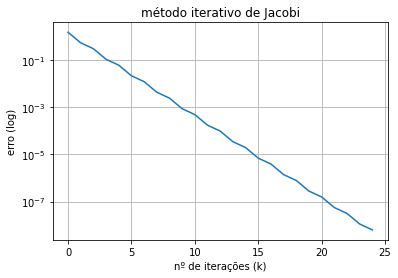

In [10]:
import numpy as np
n_int = 30
k = 0
n = 2
x_ant = [0., 0.]
x_pro = [0., 0.]
p_min = 10**-8               # precisão mínima para parada
p_k = 1.                     # precisao obtida na iteracao k
p = [1., 1.]                 # vetor que armazena as precisoes na iteracao k
p_vetor = np.zeros(n_int)    # vetor que armazena a MAIOR das precisoes na iteracao k
print('k = ', k, '  x_pro = ', np.matrix(x_ant))
while (k<n_int)and(p_k>p_min):
  x_pro[0] = x_ant[1]*D[0][1] + c[0]
  x_pro[1] = x_ant[0]*D[1][0] + c[1]
  p[0] = np.fabs(x_pro[0] - x_ant[0])
  p[1] = np.fabs(x_pro[1] - x_ant[1])
  if (p[0] > p[1]):
     p_k = p[0]
  else:
     p_k = p[1]
  p_vetor[k] = p_k
  print('k = ', k+1, '  x_pro = ', x_pro[0],'  ',x_pro[1], '  p[0] = ', p[0], '  p[1] = ', p[1])
  x_ant[0] = x_pro[0]
  x_ant[1] = x_pro[1]
  k = k+1
 
print('')
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
plt.plot(range(0,k,1), p_vetor[0:k])   # grafico do maior "erro" (eixo y) em cada iteração k (eixo x)
plt.xlabel('nº de iterações (k)') 
plt.ylabel('erro (log)') 
plt.title('método iterativo de Jacobi')
plt.grid()
plt.yscale('log')     # escala logaritmica no eixo y (erro)
plt.show()

O sistema convergiu em 25 iterações. O gráfico acima (nºiterações x erro (na escala log)) ilustra como ocorre o decaimento do "erro".


*(c)* Aplicando o método de Jacobi para a segunda solução inicial  $\mathbf{x}^{(0)} =  \mathbf{x}_{ant} =(-100.;300.)$

k =  0   x_pro =  [[-100.  300.]]
k =  1   x_pro =  -167.1875    -34.83870967741935   p[0] =  67.1875   p[1] =  334.83870967741933
k =  2   x_pro =  21.159274193548384    -58.67943548387097   p[0] =  188.34677419354838   p[1] =  23.840725806451616
k =  3   x_pro =  34.569682459677416    8.153290842872007   p[0] =  13.410408266129032   p[1] =  66.83272632674297
k =  4   x_pro =  -3.023726099115504    12.911822808272632   p[0] =  37.59340855879292   p[1] =  4.758531965400625
k =  5   x_pro =  -5.700400329653355    -0.4277737771055016   p[0] =  2.6766742305378513   p[1] =  13.339596585378134
k =  6   x_pro =  1.8031227496218447    -1.3775614072963522   p[0] =  7.5035230792752   p[1] =  0.9497876301908507
k =  7   x_pro =  2.337378291604198    1.2849790401883965   p[0] =  0.5342555419823531   p[1] =  2.6625404474847487
k =  8   x_pro =  0.839699289894027    1.4745535873434252   p[0] =  1.4976790017101709   p[1] =  0.18957454715502875
k =  9   x_pro =  0.7330636071193233    0.94311910286562

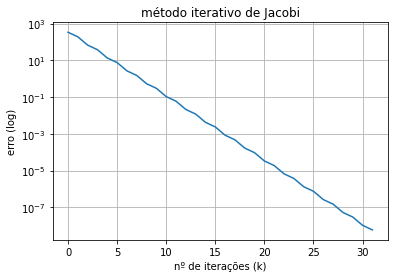

In [11]:
n_int = 40
k = 0
n = 2
x_ant = [-100., 300.]
x_pro = [0., 0.]
p_min = 10**-8               # precisão mínima para parada
p_k = 1.                     # precisao obtida na iteracao k
p = [1., 1.]                 # vetor que armazena as precisoes na iteracao k
p_vetor = np.zeros(n_int)
print('k = ', k, '  x_pro = ', np.matrix(x_ant))
while (k<n_int)and(p_k>p_min):
  x_pro[0] = x_ant[1]*D[0][1] + c[0]
  x_pro[1] = x_ant[0]*D[1][0] + c[1]
  p[0] = np.fabs(x_pro[0] - x_ant[0])
  p[1] = np.fabs(x_pro[1] - x_ant[1])
  if (p[0] > p[1]):
     p_k = p[0]
  else:
     p_k = p[1]
  p_vetor[k] = p_k
  print('k = ', k+1, '  x_pro = ', x_pro[0],'  ',x_pro[1], '  p[0] = ', p[0], '  p[1] = ', p[1])
  x_ant[0] = x_pro[0]
  x_ant[1] = x_pro[1]
  k = k+1

print('')
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
plt.plot(range(0,k,1), p_vetor[0:k]) 
plt.xlabel('nº de iterações (k)') 
plt.ylabel('erro (log)') 
plt.title('método iterativo de Jacobi')
plt.grid()
plt.yscale('log')
plt.show()

Mesmo para uma condição inicial muito distante da solução exata, o método iterativo de Jacobi foi capaz de convergir para uma solução aproximada(precisou de 32 iterações). O gráfico acima (nºiterações x erro (na escala log)) ilustra como ocorre o decaimento do "erro".

# Método Iterativo de Jacobi: questao 2 

Seja o sistema de equações lineares 
$\left\{
\begin{aligned}
    1.8x_1 + 3.2x_2     &= 5\\
    3.1x_1-1.1x_2 &= 2
\end{aligned}
\right.$ 

com solução exata $ \mathbf{x} = (1;1)$. Execute o método iterativo de Jacobi por 30 iterações, partindo da solução inicial $ \mathbf{x}^{(0)}=(0;0)$.

O sistema **Ax = b**, onde 

 $\mathbf{A} = \left[ 
  \begin{array}{c}
  1.8 & 3.2 &\\
  3.1 & -1.1 
  \end{array}
 \right]$  e  $\mathbf{b} = \left[ 
  \begin{array}{c}
  5 \\
  2
  \end{array}
 \right]$ 
 
 pode ser reescrito na forma **x = Dx + c**, onde

  $\mathbf{D} = \left[ 
  \begin{array}{c}
  0 & -3.2/1.8 \\
  3.1/1.1 & 0
  \end{array}
 \right]$  e  $\mathbf{c} = \left[ 
  \begin{array}{c}
  5/1.8 \\
  -2/1.1
  \end{array}
 \right]$

In [12]:
import numpy as np
A = [[1.8, 3.2],[3.1, -1.1]]  # matriz dos coeficientes do sistema linear
b = [5, 2]                    # vetor com os termos independentes
print('A =')
print('', np.matrix(A))
print('b =', np.matrix(b))
D = np.zeros((2,2))
D[0][1] = -A[0][1]/A[0][0]
D[1][0] = -A[1][0]/A[1][1]
c = np.zeros((2,1))
c[0] = b[0]/A[0][0]
c[1] = b[1]/A[1][1]
print('D = \n', np.matrix(D))
print('c =\n', np.matrix(c))
autovalores = np.linalg.eigvals(D)
print('autovalores de D = ',np.matrix(autovalores))
print('modulo dos autovalores = ',np.abs(autovalores))

A =
 [[ 1.8  3.2]
 [ 3.1 -1.1]]
b = [[5 2]]
D = 
 [[ 0.         -1.77777778]
 [ 2.81818182  0.        ]]
c =
 [[ 2.77777778]
 [-1.81818182]]
autovalores de D =  [[0.+2.23832549j 0.-2.23832549j]]
modulo dos autovalores =  [2.23832549 2.23832549]


A conclusão a priori, é que NÃO SABEMOS se o sistema irá CONVERGIR para uma solução!

k =  0   x_pro =  [[0. 0.]]
k =  1   x_pro =  [2.77777778]    [-1.81818182]   p[0] =  [2.77777778]   p[1] =  [1.81818182]
k =  2   x_pro =  [6.01010101]    [6.01010101]   p[0] =  [3.23232323]   p[1] =  [7.82828283]
k =  3   x_pro =  [-7.90684624]    [15.11937557]   p[0] =  [13.91694725]   p[1] =  [9.10927456]
k =  4   x_pro =  [-24.10111213]    [-24.10111213]   p[0] =  [16.19426589]   p[1] =  [39.22048771]
k =  5   x_pro =  [45.62419934]    [-69.73949782]   p[0] =  [69.72531148]   p[1] =  [45.63838569]
k =  6   x_pro =  [126.75910724]    [126.75910724]   p[0] =  [81.1349079]   p[1] =  [196.49860507]
k =  7   x_pro =  [-222.57174621]    [355.41202951]   p[0] =  [349.33085346]   p[1] =  [228.65292226]
k =  8   x_pro =  [-629.06583023]    [-629.06583023]   p[0] =  [406.49408402]   p[1] =  [984.47785974]
k =  9   x_pro =  [1121.11703153]    [-1774.64006702]   p[0] =  [1750.18286176]   p[1] =  [1145.57423679]
k =  10   x_pro =  [3157.69345248]    [3157.69345248]   p[0] =  [2036.57642096]   

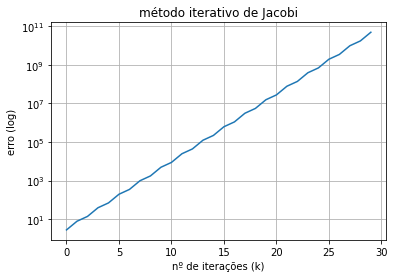

In [15]:
import numpy as np
n_int = 30
k = 0
n = 2
x_ant = [0., 0.] #  x_ant = [-100., 300.]
x_pro = [0., 0.]
p_min = 10**-8               # precisão mínima para parada
p_k = 1.                     # precisao obtida na iteracao k
p = [1., 1.]                 # vetor que armazena as precisoes na iteracao k
p_vetor = np.zeros(n_int)
print('k = ', k, '  x_pro = ', np.matrix(x_ant))
while (k<n_int)and(p_k>p_min):
  x_pro[0] = x_ant[1]*D[0][1] + c[0]
  x_pro[1] = x_ant[0]*D[1][0] + c[1]
  p[0] = np.fabs(x_pro[0] - x_ant[0])
  p[1] = np.fabs(x_pro[1] - x_ant[1])
  if (p[0] > p[1]):
     p_k = p[0]
  else:
     p_k = p[1]
  p_vetor[k] = p_k
  print('k = ', k+1, '  x_pro = ', x_pro[0],'  ',x_pro[1], '  p[0] = ', p[0], '  p[1] = ', p[1])
  x_ant[0] = x_pro[0]
  x_ant[1] = x_pro[1]
  k = k+1

import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
plt.plot(range(0,k,1), p_vetor[0:k]) 
plt.xlabel('nº de iterações (k)') 
plt.ylabel('erro (log)') 
plt.title('método iterativo de Jacobi')
plt.grid()
plt.yscale('log')
plt.show()

O processo iterativo está gerando uma sequencia de soluções, que se afasta cada vez mais da solução exata, ou seja, a solução está **divergindo!**

# Método Iterativo de Gauss-Seidel: questão 3 

Seja o sistema de equações lineares 
$\left\{
\begin{aligned}
    3.2x_1 + 1.8x_2     &= 5\\
    -1.1x_1+3.1x_2 &= 2
\end{aligned}
\right.$

com solução exata $ \mathbf{x} = (1;1)$. 

*   (a) Execute o método iterativo de Gauss-Seidel por 30 iterações, pare antes se $max(|x_i^{(k)} - x_i^{(k+1)}|) < 10^{-8}$ para $i=1,2$, partindo da solução inicial $ \mathbf{x}^{(0)}=(0;0)$.
*   (b) Refaça com a mesma condição inicial, mas invertendo a ordem das equações (calculando primeiro a segunda equação, e depois a primeira)

 

Seja a matriz **D** como definida na questão 1, então é possivel definir as matrizes triangular superior de **D**, $\mathbf{T}_{sup}(\mathbf{D})$,  e triangular inferior  de **D**, $\mathbf{T}_{inf}(\mathbf{D})$, de maneira que:

$\mathbf{T}_{inf} = \left[ 
  \begin{array}{c}
  0 & 0 \\
  d_{21} & 0
  \end{array}
 \right]$  e  $\mathbf{T}_{sup} = \left[ 
  \begin{array}{c}
  0 & d_{12} \\
  0 & 0
  \end{array}
 \right]$ onde $\mathbf{D} = \left[ 
  \begin{array}{c}
  0 & -1.8/3.2 \\
  1.1/3.1 & 0
  \end{array}
 \right]$

Dessa maneira, o processo iterativo na forma matrcial será dado por: 

$\mathbf{x}^{(k+1)} = \mathbf{T}_{sup}\mathbf{x}^{(k)} +  \mathbf{T}_{inf}\mathbf{x}^{(k+1)} +  \mathbf{c}$

Equivalementemente, o proceso iterativo em termos de equações assume a forma da seguinte configuração:  
$\left\{
\begin{aligned}
    x_1^{(k+1)} &= \frac{5-1.8x_2^{(k)}}{3.2}\\
    x_2^{(k+1)} &= \frac{2 + 1.1x_1^{(k+1)}}{3.1}
\end{aligned}
\right.$
onde $\mathbf{x}^{(0)} = (0;0)$

k =  0   x_pro =  0.0    0.0
k =  1   x_pro =  [1.5625]    [1.19959677]   p[0] =  [1.5625]   p[1] =  [1.19959677]
k =  2   x_pro =  [0.88772681]    [0.96016113]   p[0] =  [0.67477319]   p[1] =  [0.23943565]
k =  3   x_pro =  [1.02240937]    [1.00795171]   p[0] =  [0.13468255]   p[1] =  [0.04779058]
k =  4   x_pro =  [0.99552716]    [0.99841286]   p[0] =  [0.0268822]   p[1] =  [0.00953885]
k =  5   x_pro =  [1.00089276]    [1.00031679]   p[0] =  [0.0053656]   p[1] =  [0.00190392]
k =  6   x_pro =  [0.99982181]    [0.99993677]   p[0] =  [0.00107096]   p[1] =  [0.00038002]
k =  7   x_pro =  [1.00003557]    [1.00001262]   p[0] =  [0.00021376]   p[1] =  [7.58501419e-05]
k =  8   x_pro =  [0.9999929]    [0.99999748]   p[0] =  [4.26657048e-05]   p[1] =  [1.51394437e-05]
k =  9   x_pro =  [1.00000142]    [1.0000005]   p[0] =  [8.51593706e-06]   p[1] =  [3.02178412e-06]
k =  10   x_pro =  [0.99999972]    [0.9999999]   p[0] =  [1.69975357e-06]   p[1] =  [6.03138362e-07]
k =  11   x_pro =  [1.000

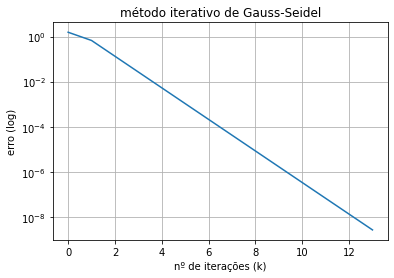

In [16]:
import numpy as np
n_int = 30
A = [[3.2, 1.8],[-1.1, 3.1]]  # matriz dos coeficientes do sistema linear
b = [5, 2]                    # vetor com os termos independentes
D = np.zeros((2,2))
D[0][1] = -A[0][1]/A[0][0]
D[1][0] = -A[1][0]/A[1][1]
c = np.zeros((2,1))
c[0] = b[0]/A[0][0]
c[1] = b[1]/A[1][1]
p_min = 10**-8               # precisão mínima para parada
p_k = 1.                     # precisao obtida na iteracao k
p = [1., 1.]                 # vetor que armazena as precisoes na iteracao k
p_vetor = np.zeros(n_int)
k = 0
x_ant = [0., 0.]
x_pro = [0., 0.]
print('k = ', 0, '  x_pro = ', x_ant[0],'  ',x_ant[1])
while (k<n_int)and(p_k>p_min):
  x_pro[0] = x_ant[1]*D[0][1] + c[0]
  x_pro[1] = x_pro[0]*D[1][0] + c[1]
  p[0] = np.fabs(x_pro[0] - x_ant[0])
  p[1] = np.fabs(x_pro[1] - x_ant[1])
  if (p[0] > p[1]):
     p_k = p[0]
  else:
     p_k = p[1]
  p_vetor[k] = p_k
  print('k = ', k+1, '  x_pro = ', x_pro[0],'  ',x_pro[1], '  p[0] = ', p[0], '  p[1] = ', p[1])
  x_ant[0] = x_pro[0]
  x_ant[1] = x_pro[1]
  k = k+1

import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
plt.plot(range(0,k,1), p_vetor[0:k]) 
plt.xlabel('nº de iterações (k)') 
plt.ylabel('erro (log)') 
plt.title('método iterativo de Gauss-Seidel')
plt.grid()
plt.yscale('log')
plt.show()

implementação da seguinte configuração:  
$\left\{
\begin{aligned}
    x_2^{(k+1)} &= \frac{2 + 1.1x_1^{(k)}}{3.1}\\
    x_1^{(k+1)} &= \frac{5-1.8x_2^{(k+1)}}{3.2}
\end{aligned}
\right.$
onde $\mathbf{x}^{(0)} = (0;0)$

k =  0   x_pro =  [[0. 0.]]
k =  1   x_pro =  [[1.19959677 0.64516129]]   p[0] =  1.1995967741935483   p[1] =  0.6451612903225806
k =  2   x_pro =  [[0.96016113 1.07082466]]   p[0] =  0.23943564646201854   p[1] =  0.42566337148803324
k =  3   x_pro =  [[1.00795171 0.98586363]]   p[0] =  0.047790582660765746   p[1] =  0.08496103584136139
k =  4   x_pro =  [[0.99841286 1.00282157]]   p[0] =  0.009538846135919044   p[1] =  0.01695794868607814
k =  5   x_pro =  [[1.00031679 0.99943682]]   p[0] =  0.0019039229182581385   p[1] =  0.003384751854680901
k =  6   x_pro =  [[0.99993677 1.00011241]]   p[0] =  0.0003800168727975395   p[1] =  0.0006755855516399345
k =  7   x_pro =  [[1.00001262 0.99997756]]   p[0] =  7.585014194944062e-05   p[1] =  0.00013484469679914124
k =  8   x_pro =  [[0.99999748 1.00000448]]   p[0] =  1.5139443655165508e-05   p[1] =  2.6914566498059678e-05
k =  9   x_pro =  [[1.0000005  0.99999911]]   p[0] =  3.0217841167079484e-06   p[1] =  5.372060651764876e-06
k =  10   x_p

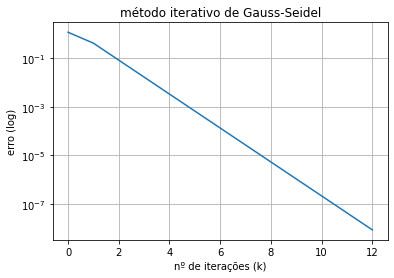

In [17]:
import numpy as np
n_int = 30
k = 0
n = 2
A = [[3.2, 1.8],[-1.1, 3.1]]
b = [5, 2]
x_ant = [0., 0.]
x_pro = [0., 0.]
p_min = 10**-8               # precisão mínima para parada
p_k = 1.                     # precisao obtida na iteracao k
p_vetor = np.zeros(n_int)
p = [1., 1.]                 # vetor que armazena as precisoes na iteracao k
print('k = ', k, '  x_pro = ', np.matrix(x_ant))
while (k<n_int)and(p_k > p_min):
  x_pro[1] = (b[1] - x_ant[0]*A[1][0])/A[1][1]
  x_pro[0] = (b[0] - x_pro[1]*A[0][1])/A[0][0]
  p[0] = np.fabs(x_pro[0] - x_ant[0])
  p[1] = np.fabs(x_pro[1] - x_ant[1])
  if (p[0] > p[1]):
     p_k = p[0]
  else:
     p_k = p[1]
  p_vetor[k] = p_k
  print('k = ', k+1, '  x_pro = ', np.matrix(x_pro), '  p[0] = ', p[0], '  p[1] = ', p[1])
  x_ant[0] = x_pro[0]
  x_ant[1] = x_pro[1]
  k = k+1

import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
plt.plot(range(0,k,1), p_vetor[0:k])
plt.xlabel('nº de iterações (k)') 
plt.ylabel('erro (log)') 
plt.title('método iterativo de Gauss-Seidel') 
plt.grid()
plt.yscale('log')
plt.show()

O método de Gauss-Seidel "acerela" o processo de convergência, se comparado com o método de Jacobi.

# Comparação entre os métodos: questão 4

Sabendo que a quantidade de operações matemáticas executadas pelos métodos de Jacobi e de Gauss-Seidel, para cada iteração, para um sistema de equações lineares de dimensão $n$, é dada por:

$N_{ope} = N_{adi} + N_{mul} + N_{div} $ , onde

$N_{adi} = n(n-1)$ é o número de adições ou subtrações

$N_{mul} = n(n-1)$ é o número de multiplicações

$N_{div} = n$ é o número de divisões

Compare os resultados obtidos em Q01(b) e Q03(a).


$N_{ope}(Jac) = 25*(2 + 2 + 2) = 150$ e $N_{ope}(G-Sei) = 14*(2 + 2 + 2) = 84$, portanto cerca de 56% de diferença.    

 


# Atividade para casa

Será mesmo que o método de Gauss-Seidel sempre "acelera" o processo de convergência, quando comparado com o método de Jacobi? Façamos um teste. Sejam os sistemas de equações lineares

 
 $S_1 = \left\{
\begin{aligned}
    x_1 + 2x_2 - 2x_3     &= 1\\
    x_1 + x_2 + x_3 &= 3\\
    2x_1 + 2x_2 + x_3 &= 5\\
\end{aligned}
\right. $  

e

 $S_2 = \left\{
\begin{aligned}
    5x_1 + 3x_2 + 4x_3     &= 12\\
    3x_1 + 6x_2 + 6x_3 &= 13\\
    4x_1 + 4x_2 + 5x_3 &= 13\\
\end{aligned}
\right. $

ambos com solução exata $ \mathbf{x} = (1;1;1)$. Para estas condições faça:
* (a) partindo da condição inicial $ \mathbf{x}^{(0)}=(0;0;0)$, encontre a solução aproximada de $S_1$ e de $S_2$  pelos métodos de Jacobi e de Gauss-Seidel, com critério de parada 30 iterações. Compare os quatros resultados numéricos obtidos.
* (b) calcule os autovalores das matrizes **D** associadas aos sistemas $\mathbf{S}_1$ e  $\mathbf{S}_2$. O que pode ser concluído quando combinado aos resultados obtidos no item (a) ?